# **Classical vs Quantum Similarity-Based Attack Characterization**

## **Loads & Imports**

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import KNeighborsClassifier

In [5]:
import joblib

try:
    obj = joblib.load("random_forest.pkl")
    print(type(obj))
except Exception as e:
    print(e)

<class 'sklearn.pipeline.Pipeline'>


In [6]:
rf_model = joblib.load("random_forest.pkl")

label_encoder = joblib.load("label_encoder.pkl")

In [7]:
import os

print(os.path.getsize("random_forest.pkl"))
print(os.path.getsize("label_encoder.pkl"))

47264962
491


In [8]:
train = pd.read_csv("KDDTrain.csv")
test = pd.read_csv("KDDTest.csv")

In [9]:
# attack rows in train set

(train["label"] != "normal").sum()

np.int64(58630)

## **Binary Intrusion Detection**

In [10]:
x_test = test.drop(
    columns=["label", "difficulty_level"]
)

predictions = rf_model.predict(x_test)

predictions = label_encoder.inverse_transform(
    predictions
)

In [11]:
test["binary_prediction"] = predictions

test["binary_prediction"].value_counts()

,count
binary_prediction,
normal,14205
attack,8339


In [12]:
attack_data = test[test["binary_prediction"] == "attack"].copy()

print(attack_data.shape)

(8339, 44)


In [13]:
print("Unique attack labels predicted as attack:\n")

print(sorted(attack_data["label"].unique()))

print("\nCount:", len(attack_data["label"].unique()))

Unique attack labels predicted as attack:

['apache2', 'back', 'buffer_overflow', 'ftp_write', 'httptunnel', 'ipsweep', 'land', 'mscan', 'multihop', 'named', 'neptune', 'nmap', 'normal', 'perl', 'phf', 'pod', 'portsweep', 'processtable', 'ps', 'saint', 'satan', 'smurf', 'sqlattack', 'teardrop', 'udpstorm', 'warezmaster', 'xsnoop', 'xterm']

Count: 28


In [14]:
attack_detection = (
    test.groupby("label")["binary_prediction"]
    .apply(lambda x: (x == "attack").mean())
    .sort_values())

attack_detection

,binary_prediction
label,
imap,0.000000
guess_passwd,0.000000
mailbomb,0.000000
loadmodule,0.000000
sendmail,0.000000
snmpgetattack,0.000000
snmpguess,0.000000
rootkit,0.000000
worm,0.000000


In [15]:
attack_data.to_csv("attack_only_predictions.csv", index=False)

In [16]:
attack_data.shape

(8339, 44)

Random Forest achieved high **precision (96.9%)** but moderate **recall (63.0%)**.

----

The model **successfully detected most DoS and Probe attacks** but **struggled with low-frequency attack categories such as R2L and U2R**.

----

Several attack types present in the testing dataset were never classified as attacks and therefore did not reach the attack characterization stage.

----

This observation motivates the need for **behavior-based characterization methods** capable of providing additional insights beyond conventional supervised detection.

# **Family Defintion**

Where do attack families come from?
- Not from model.
- Not from clustering.
- Not from QSVC.

They come from the NSL-KDD benchmark itself.


**NSL-KDD** is officially derived from **KDD'99**, and every attack label belongs to one of **four attack families**:

| Family | Attack Labels                                          |
| ------ | ------------------------------------------------------ |
| DoS    | neptune, smurf, back, teardrop, pod, land              |
| Probe  | satan, ipsweep, portsweep, nmap                        |
| R2L    | guess_passwd, ftp_write, warezclient, warezmaster, etc |
| U2R    | buffer_overflow, rootkit, perl, loadmodule             |


In [17]:
attack_data = pd.read_csv("attack_only_predictions.csv")

print(attack_data.shape)

(8339, 44)


In [18]:
dos = [
    "neptune",
    "smurf",
    "back",
    "teardrop",
    "pod",
    "land"
]

probe = [
    "ipsweep",
    "portsweep",
    "nmap",
    "satan"
]

r2l = [
    "guess_passwd",
    "ftp_write",
    "imap",
    "phf",
    "multihop",
    "warezmaster",
    "warezclient",
    "spy"
]

u2r = [
    "buffer_overflow",
    "loadmodule",
    "rootkit",
    "perl"
]

**Create Family Labels (Training Attacks Only)**

In [19]:
def attack_family(label):

    if label == "normal":
        return "normal"

    elif label in dos:
        return "dos"

    elif label in probe:
        return "probe"

    elif label in r2l:
        return "r2l"

    elif label in u2r:
        return "u2r"

    return "unknown"

**Build Family Training Dataset**

In [20]:
train_attacks = train[
    train["label"] != "normal"
].copy()

train_attacks["family"] = (
    train_attacks["label"]
    .apply(attack_family)
)

train_attacks = train_attacks.dropna()

print(train_attacks.shape)

train_attacks["family"].value_counts()

(58630, 44)


,count
family,
dos,45927
probe,11656
r2l,995
u2r,52


### **Similarity Dataset Preparation**

In [21]:
# Convert attack records into numerical feature vectors.

drop_cols = [
    "label",
    "difficulty_level",
    "family"
]

x_train = train_attacks.drop(
    columns=drop_cols
)

y_family = train_attacks["family"]

**Feature Encoding**

In [22]:
cat_cols = [
    "protocol_type",
    "service",
    "flag"
]

num_cols = [
    c for c in x_train.columns
    if c not in cat_cols
]

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols
        ),
        (
            "num",
            StandardScaler(),
            num_cols
        )
    ]
)

**Transform Features**

In [24]:
x_train_processed = (
    preprocessor.fit_transform(x_train)
)

print(x_train_processed.shape)

(58630, 118)


## **PCA Reduction**

In [27]:
# For cosine similiarity and quantum experiments

pca = PCA(n_components=20, random_state=42)

x_train_pca = pca.fit_transform(x_train_processed)

x_train_pca.shape

(58630, 20)

### **Family Centroids**

In [29]:
# Classical Similarity Knowledge Base

family_df = pd.DataFrame(x_train_pca)

family_df["family"] = y_family.values

In [31]:
family_centroids = (family_df.groupby("family").mean())

family_centroids

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
family,,,,,,,,,,,,,,,,,,,,
dos,0.999952,0.098733,0.028705,0.011243,0.255846,0.041927,-0.222074,0.106912,0.128190,0.009007,-0.029702,0.012572,0.068658,0.031117,0.031790,0.014679,-0.014143,0.001265,-0.017835,0.034642
probe,-3.611834,-0.101061,-0.435952,-0.580694,-0.902272,-0.134800,0.857437,-0.453197,-0.501694,-0.043564,0.029488,-0.030264,-0.215252,-0.132263,-0.069223,-0.134342,-0.038484,0.009682,0.156748,-0.109338
r2l,-3.636951,-3.171848,2.912725,6.454539,-1.199250,-0.352789,0.224608,0.438407,0.008839,0.243546,0.922571,-0.207008,-0.620886,0.174749,-0.903250,0.531369,0.355177,-0.119604,-0.919924,-0.366001
u2r,-3.971255,-3.856696,16.633470,-3.270098,-0.771305,-0.064352,-0.356965,-1.229013,-0.931041,-2.850330,1.970447,-0.359293,-0.509840,-1.179736,4.722324,6.981185,14.320946,-0.998989,-1.781062,0.915541


# **Unseen Attack Dataset**

In [32]:
# Attacks never seen during training

unseen_attacks = sorted(set(test["label"]) - set(train["label"]))

unseen_attacks

['apache2',
 'httptunnel',
 'mailbomb',
 'mscan',
 'named',
 'processtable',
 'ps',
 'saint',
 'sendmail',
 'snmpgetattack',
 'snmpguess',
 'sqlattack',
 'udpstorm',
 'worm',
 'xlock',
 'xsnoop',
 'xterm']

**Ground Truth For Evaluation**

In [35]:
# not for training, only for evaluation

unseen_mapping = {

    "apache2": "dos",
    "mailbomb": "dos",
    "processtable": "dos",
    "udpstorm": "dos",

    "mscan": "probe",
    "saint": "probe",

    "httptunnel": "r2l",
    "named": "r2l",
    "sendmail": "r2l",
    "snmpgetattack": "r2l",
    "snmpguess": "r2l",
    "xlock": "r2l",
    "xsnoop": "r2l",

    "ps": "u2r",
    "sqlattack": "u2r",
    "xterm": "u2r"
}

# **Classical Cosine Similarity**

In [40]:
results = []

for attack in unseen_attacks:

    if attack == "worm":
        continue

    sample = test[
        test["label"] == attack
    ].head(1)

    sample_x = sample.drop(
        columns=[
            "label",
            "difficulty_level"
        ]
    )

    sample_processed = (
        preprocessor.transform(sample_x)
    )

    sample_pca = (
        pca.transform(
            sample_processed
        )
    )

    sim = cosine_similarity(
        sample_pca,
        family_centroids
    )

    pred_family = (
        family_centroids.index[
            np.argmax(sim)
        ]
    )

    confidence = (np.max(sim))

    results.append([
        attack,
        unseen_mapping[attack],
        pred_family,
        confidence
    ])

    print(results)

[['apache2', 'dos', 'r2l', np.float64(0.5933766128958862)]]
[['apache2', 'dos', 'r2l', np.float64(0.5933766128958862)], ['httptunnel', 'r2l', 'probe', np.float64(0.5251356283666371)]]
[['apache2', 'dos', 'r2l', np.float64(0.5933766128958862)], ['httptunnel', 'r2l', 'probe', np.float64(0.5251356283666371)], ['mailbomb', 'dos', 'r2l', np.float64(0.6546658364289228)]]
[['apache2', 'dos', 'r2l', np.float64(0.5933766128958862)], ['httptunnel', 'r2l', 'probe', np.float64(0.5251356283666371)], ['mailbomb', 'dos', 'r2l', np.float64(0.6546658364289228)], ['mscan', 'probe', 'probe', np.float64(0.8311145453036511)]]
[['apache2', 'dos', 'r2l', np.float64(0.5933766128958862)], ['httptunnel', 'r2l', 'probe', np.float64(0.5251356283666371)], ['mailbomb', 'dos', 'r2l', np.float64(0.6546658364289228)], ['mscan', 'probe', 'probe', np.float64(0.8311145453036511)], ['named', 'r2l', 'probe', np.float64(0.7744262550293247)]]
[['apache2', 'dos', 'r2l', np.float64(0.5933766128958862)], ['httptunnel', 'r2l', '

### **Evaluation & Results**

In [41]:
cosine_results = pd.DataFrame(
    results,
    columns=[
        "Attack",
        "Actual Family",
        "Predicted Family",
        "Similarity Score"
    ]
)

cosine_results

,Attack,Actual Family,Predicted Family,Similarity Score
0,apache2,dos,r2l,0.593377
1,httptunnel,r2l,probe,0.525136
2,mailbomb,dos,r2l,0.654666
3,mscan,probe,probe,0.831115
4,named,r2l,probe,0.774426
5,processtable,dos,probe,0.358346
6,ps,u2r,u2r,0.582917
7,saint,probe,probe,0.701298
8,sendmail,r2l,u2r,0.188216
9,snmpgetattack,r2l,probe,0.627883


In [44]:
acc = accuracy_score(
    cosine_results["Actual Family"],
    cosine_results["Predicted Family"]
)

print(f"Accuracy: {acc:.4f}")

Accuracy: 0.3750


In [47]:
print(
    classification_report(
        cosine_results["Actual Family"],
        cosine_results["Predicted Family"]
    )
)

              precision    recall  f1-score   support

         dos       0.00      0.00      0.00         4
       probe       0.25      1.00      0.40         2
         r2l       0.33      0.14      0.20         7
         u2r       0.75      1.00      0.86         3

    accuracy                           0.38        16
   macro avg       0.33      0.54      0.36        16
weighted avg       0.32      0.38      0.30        16



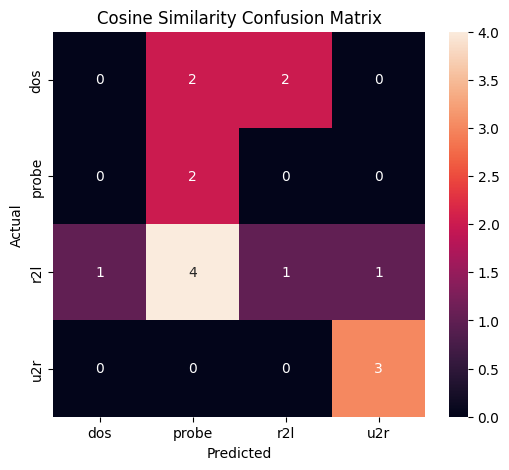

In [75]:
cm = confusion_matrix(
    cosine_results["Actual Family"],
    cosine_results["Predicted Family"],
    labels=["dos","probe","r2l","u2r"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["dos","probe","r2l","u2r"],
    yticklabels=["dos","probe","r2l","u2r"]
)

plt.title("Cosine Similarity Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "cosine_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## **Cosine Similarity Results**

Cosine similarity was evaluated on 16 attack types that were not present in the NSL-KDD training set.




• Overall characterization accuracy was **37.5%**, indicating that **simple centroid-based similarity is insufficient** for reliable attack-family assignment.

• **Probe and U2R attacks:** Showed **stronger clustering behavior**, achieving higher recall compared to DoS and R2L categories.

• **DoS attacks:** Several (apache2, mailbomb, processtable, udpstorm) were **incorrectly assigned** to other families, suggesting **overlap in feature-space representations**.

• **R2L attacks:** Exhibited substantial confusion with Probe attacks, reflecting the known challenge of distinguishing **low-frequency** attack categories in NSL-KDD.

### **Family-Level Analysis**

| Family | Observation |
|----------|-------------|
| DoS | No unseen DoS attacks were correctly characterized. |
| Probe | Both unseen Probe attacks were assigned correctly. |
| R2L | High confusion with Probe and U2R families. |
| U2R | Strongest performing family with all samples correctly characterized. |

The results suggest that attack families with more distinctive behavioral patterns are easier to characterize using similarity-based methods.

### **Why Move Beyond Cosine Similarity?**

Cosine similarity compares each attack against a **single family centroid**.

This approach ignores local neighborhood structure and intra-family variation.




To address this limitation, the next experiment uses **K-Nearest Neighbours (KNN)**, which compares an attack against **multiple known attack instances rather than a single average representation**.

This provides a stronger classical baseline before introducing quantum-kernel similarity methods.

# **K-Nearest Neighbours Attack**


- Unlike cosine similarity, which compares attacks against a single family centroid,
KNN characterizes attacks by **examining their nearest known attack neighbours**.

- This allows local **behavioural patterns within attack families to be preserved**
and provides a stronger classical similarity baseline.

In [49]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean"
)

knn.fit(x_train_pca, y_family)

KNeighborsClassifier(metric='euclidean')

**Build Unseen Attack Evaluation Set**

In [53]:
evaluation_rows = []

for attack in unseen_attacks:

    if attack == "worm":
        continue

    sample = test[
        test["label"] == attack
    ].head(1)

    sample_x = sample.drop(
        columns=[
            "label",
            "difficulty_level"
        ]
    )

    sample_processed = (
        preprocessor.transform(sample_x)
    )

    sample_pca = (
        pca.transform(
            sample_processed
        )
    )

    prediction = knn.predict(
        sample_pca
    )[0]

    confidence = np.max(
        knn.predict_proba(sample_pca)
    )

    evaluation_rows.append([
        attack,
        unseen_mapping[attack],
        prediction,
        confidence
    ])

    print(evaluation_rows)

[['apache2', 'dos', 'dos', np.float64(1.0)]]
[['apache2', 'dos', 'dos', np.float64(1.0)], ['httptunnel', 'r2l', 'probe', np.float64(1.0)]]
[['apache2', 'dos', 'dos', np.float64(1.0)], ['httptunnel', 'r2l', 'probe', np.float64(1.0)], ['mailbomb', 'dos', 'dos', np.float64(1.0)]]
[['apache2', 'dos', 'dos', np.float64(1.0)], ['httptunnel', 'r2l', 'probe', np.float64(1.0)], ['mailbomb', 'dos', 'dos', np.float64(1.0)], ['mscan', 'probe', 'probe', np.float64(0.8)]]
[['apache2', 'dos', 'dos', np.float64(1.0)], ['httptunnel', 'r2l', 'probe', np.float64(1.0)], ['mailbomb', 'dos', 'dos', np.float64(1.0)], ['mscan', 'probe', 'probe', np.float64(0.8)], ['named', 'r2l', 'probe', np.float64(1.0)]]
[['apache2', 'dos', 'dos', np.float64(1.0)], ['httptunnel', 'r2l', 'probe', np.float64(1.0)], ['mailbomb', 'dos', 'dos', np.float64(1.0)], ['mscan', 'probe', 'probe', np.float64(0.8)], ['named', 'r2l', 'probe', np.float64(1.0)], ['processtable', 'dos', 'dos', np.float64(1.0)]]
[['apache2', 'dos', 'dos', np.

### **Evaluation & Results**

In [54]:
knn_results = pd.DataFrame(
    evaluation_rows,
    columns=[
        "Attack",
        "Actual Family",
        "Predicted Family",
        "Confidence"
    ]
)

knn_results

,Attack,Actual Family,Predicted Family,Confidence
0,apache2,dos,dos,1.0
1,httptunnel,r2l,probe,1.0
2,mailbomb,dos,dos,1.0
3,mscan,probe,probe,0.8
4,named,r2l,probe,1.0
5,processtable,dos,dos,1.0
6,ps,u2r,u2r,1.0
7,saint,probe,probe,1.0
8,sendmail,r2l,r2l,1.0
9,snmpgetattack,r2l,probe,0.4


In [56]:
knn_acc = accuracy_score(
    knn_results["Actual Family"],
    knn_results["Predicted Family"]
)

print(f"Accuracy: {knn_acc:.4f}")

Accuracy: 0.4375


In [57]:
print(
    classification_report(
        knn_results["Actual Family"],
        knn_results["Predicted Family"]
    )
)

              precision    recall  f1-score   support

         dos       0.75      0.75      0.75         4
       probe       0.25      1.00      0.40         2
         r2l       0.33      0.14      0.20         7
         u2r       1.00      0.33      0.50         3

    accuracy                           0.44        16
   macro avg       0.58      0.56      0.46        16
weighted avg       0.55      0.44      0.42        16



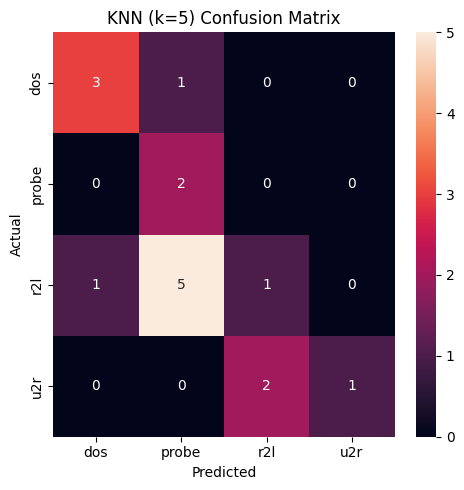

In [88]:
cm_k5 = confusion_matrix(
    knn_results["Actual Family"],
    knn_results["Predicted Family"],
    labels=["dos","probe","r2l","u2r"]
)

plt.figure(figsize=(5,5))

sns.heatmap(
    cm_k5,
    annot=True,
    fmt="d",
    xticklabels=["dos","probe","r2l","u2r"],
    yticklabels=["dos","probe","r2l","u2r"]
)

plt.title("KNN (k=5) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "knn_k5_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Example Characterization Output**

In [59]:
sample_attack = "apache2"

row = knn_results[
    knn_results["Attack"] == sample_attack
]

row

,Attack,Actual Family,Predicted Family,Confidence
0,apache2,dos,dos,1.0


**Save Results**

In [87]:
cosine_results.to_csv(
    "cosine_similarity_results.csv",
    index=False
)

knn_results.to_csv(
    "knn_k5_predictions.csv",
    index=False
)

### **KNN Hyperparameter Analysis**

In [66]:
results = []

for k in [1,3,5,7,9,11,15]:

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    knn.fit(
        x_train_pca,
        y_family
    )

    preds = []

    for attack in unseen_attacks:

        if attack == "worm":
            continue

        sample = test[
            test["label"] == attack
        ].head(1)

        sample_x = sample.drop(
            columns=[
                "label",
                "difficulty_level"
            ]
        )

        sample_processed = (
            preprocessor.transform(sample_x)
        )

        sample_pca = (
            pca.transform(sample_processed)
        )

        pred = knn.predict(
            sample_pca
        )[0]

        preds.append(pred)

    actual = [
        unseen_mapping[a]
        for a in unseen_attacks
        if a != "worm"
    ]

    acc = accuracy_score(
        actual,
        preds
    )

    results.append([k, acc])

knn_tuning = pd.DataFrame(
    results,
    columns=[
        "K",
        "Accuracy"
    ]
)

knn_tuning

,K,Accuracy
0,1,0.5625
1,3,0.5000
2,5,0.4375
3,7,0.5000
4,9,0.5000
5,11,0.5000
6,15,0.3750


- **K=1 performs best**
- Accuracy decreases as K increases
- Large K values start blending attack families together
- Rare families (especially R2 & U2R) get overwhelmed by majority-family neighbors

---

For NSL-KDD this is expected because:

- normal : 67343
- dos    : 45927
- probe  : 11656
- r2l    :   995
- u2r    :    52

**U2R has only 52 training samples.**

---

**When K becomes 15:**
Those 52 samples get drowned out neighbors are mostly DoS/Probe
performance drops

In [83]:
knn_k1 = KNeighborsClassifier(
    n_neighbors=1
)

knn_k1.fit(
    x_train_pca,
    y_family
)

evaluation_rows_k1 = []

for attack in unseen_attacks:

    if attack == "worm":
        continue

    sample = test[
        test["label"] == attack
    ].head(1)

    sample_x = sample.drop(
        columns=[
            "label",
            "difficulty_level"
        ]
    )

    sample_processed = (
        preprocessor.transform(sample_x)
    )

    sample_pca = (
        pca.transform(sample_processed)
    )

    pred = knn_k1.predict(
        sample_pca
    )[0]

    evaluation_rows_k1.append([
        attack,
        unseen_mapping[attack],
        pred
    ])

knn_k1_results = pd.DataFrame(
    evaluation_rows_k1,
    columns=[
        "Attack",
        "Actual Family",
        "Predicted Family"
    ]
)

knn_k1_results

,Attack,Actual Family,Predicted Family
0,apache2,dos,dos
1,httptunnel,r2l,probe
2,mailbomb,dos,dos
3,mscan,probe,probe
4,named,r2l,probe
5,processtable,dos,dos
6,ps,u2r,u2r
7,saint,probe,probe
8,sendmail,r2l,r2l
9,snmpgetattack,r2l,u2r


In [89]:
knn_results.to_csv(
    "knn_k1_predictions.csv",
    index=False
)

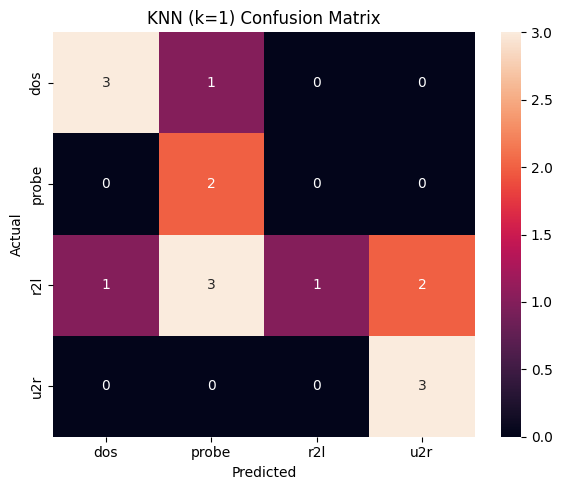

In [90]:
knn = KNeighborsClassifier(
    n_neighbors=1
)

cm_k1 = confusion_matrix(
    knn_k1_results["Actual Family"],
    knn_k1_results["Predicted Family"],
    labels=["dos","probe","r2l","u2r"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_k1,
    annot=True,
    fmt="d",
    xticklabels=["dos","probe","r2l","u2r"],
    yticklabels=["dos","probe","r2l","u2r"]
)

plt.title("KNN (k=1) Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "knn_k1_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

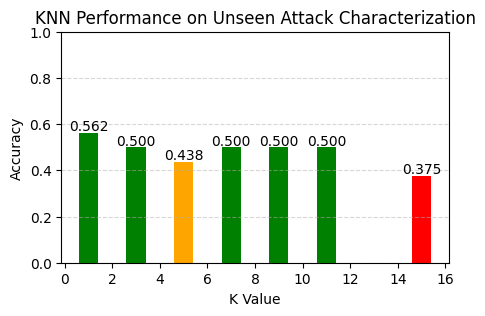

In [74]:
colors = []

for acc in knn_tuning["Accuracy"]:
    if acc >= 0.50:
        colors.append("green")
    elif acc >= 0.40:
        colors.append("orange")
    else:
        colors.append("red")

plt.figure(figsize=(5,3))

bars = plt.bar(
    knn_tuning["K"],
    knn_tuning["Accuracy"],
    color=colors
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center"
    )

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Performance on Unseen Attack Characterization")
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.savefig("knn_parameter_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

**The best performance was achieved at K=1**, suggesting that **local behavioral similarity provided more useful information than broader neighborhood voting**.

Larger K values introduced **influence from dominant** attack families, **reducing characterization accuracy** for rare attack categories.